In [10]:
from torchvision import datasets
import torch
data_folder = '~/data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download = True, train = True) #imports e download do fmnist

100%|█████████████████████████████████████| 26.4M/26.4M [00:12<00:00, 2.15MB/s]
100%|██████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 132kB/s]
100%|█████████████████████████████████████| 4.42M/4.42M [00:02<00:00, 2.00MB/s]
100%|█████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 11.3MB/s]


In [11]:
tr_images = fmnist.data
tr_targets = fmnist.targets #dados do fmnist

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np #imports

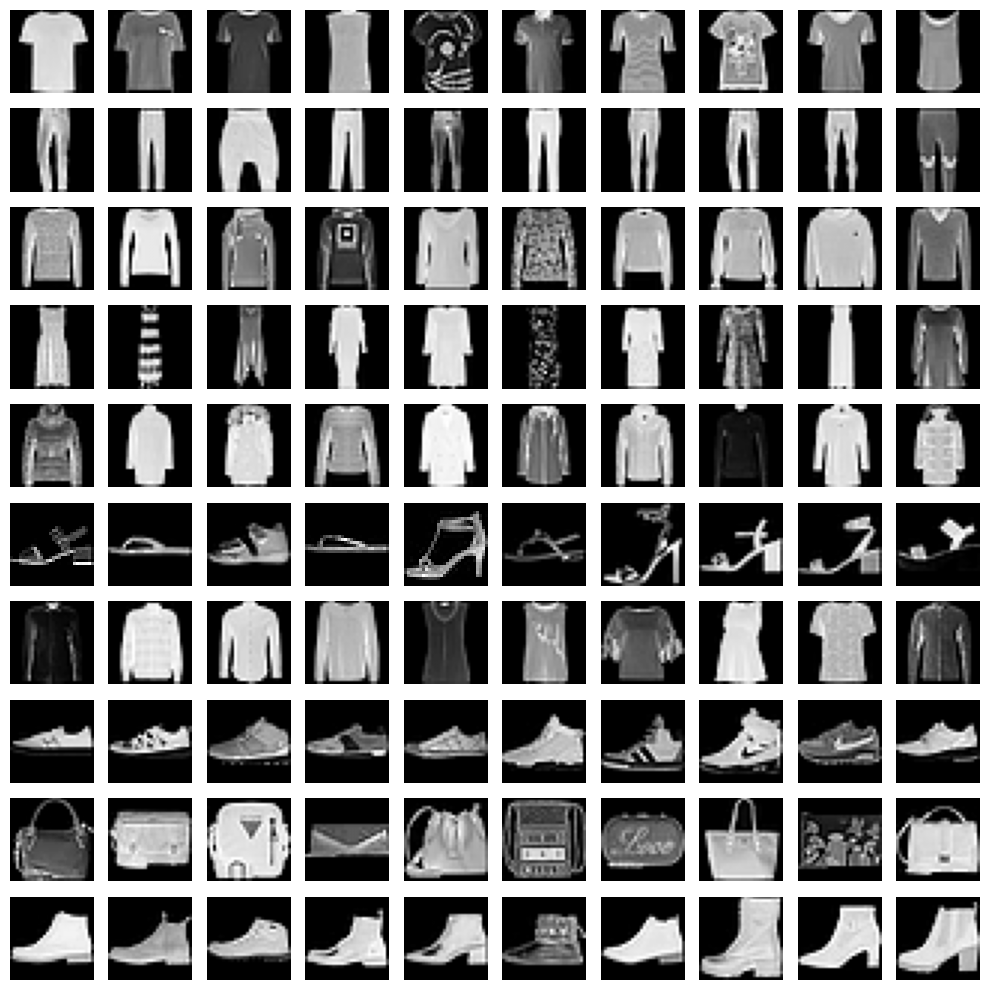

In [16]:
R, C = len(tr_targets.unique()), 10 #100 imagens, e 10 classes
fig, ax = plt.subplots(R, C, figsize = (10,10)) #faz a figura
for label_class, plot_row in enumerate(ax): 
    label_x_rows = np.where(tr_targets == label_class)[0] #indice das imagens
    for plot_cell in plot_row:
     plot_cell.grid(False); plot_cell.axis('off')
     ix = np.random.choice(label_x_rows)
     x, y = tr_images[ix], tr_targets[ix]
     plot_cell.imshow(x, cmap='gray') #coloca tudo em cinza
plt.tight_layout() #ele pega 100 imagens e pra cada linha tem 10 imagens de uma mesma classe, mas pra outra linha e outra classe

In [29]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu" #se vai rodar na gpu ou cpu
from torchvision import datasets #imports

In [18]:
class FMNISTDataset(Dataset): #classe pro dataset
    def __init__(self, x, y): 
        x = x.float() #converte pra float
        x = x.view(-1, 28*28) #diminui a imagem
        self.x, self.y = x, y 
    def __getitem__(self, idx):  #funcao q pega a imagem
        x, y = self.x[idx], self.y[idx] 
        return x.to(device), y.to(device)
    def __len__(self): #funcao q retorna a qntd de imagens
        return len(self.x)

In [19]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets) #pega os dados
    trn_dl = DataLoader(train, batch_size = 32, shuffle = True) #embaralha
    return trn_dl

In [30]:
from torch.optim import SGD
def get_model(): #cria o modelo
    model = nn.Sequential( 
        nn.Linear(28 * 28, 1000), #camada q recebe a imagem
        nn.ReLU(), #ativacao
        nn.Linear(1000, 10) #pegas os 1000 q a entrada faz e colo em 10 de saida
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()  #funcao de perda
    optimizer = SGD(model.parameters(), lr = 1e-2) #otimizador
    return model, loss_fn, optimizer

In [26]:
@torch.no_grad()
def accuracy(x, y, model):
    model.eval() 
    prediction = model(x) #faz um teste do modelo
    max_values, argmaxes = prediction.max(-1) 
    is_correct = argmaxes == y #ve se acertou
    return is_correct.cpu().numpy().tolist()

In [27]:
def train_batch(x, y, model, opt, loss_fn):
    model.train() #treina o modelo
    prediction = model(x) 
    batch_loss = loss_fn(prediction, y) #ve o erro
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad() #atualiza os pesos
    return batch_loss.item()

In [31]:
trn_dl = get_data() #pega os dados
model, loss_fn, optimizer = get_model() #joga pro modelo

In [32]:
losses, accuracies = [], [] #lista de erro e acuracia
for epoch in range(5): #5 epochs
    print(epoch)
    epoch_losses, epoch_accuracies = [], []
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss) #vai passando nas epochs e treianndo e pegando o valor de erro e a media do erro da epoca
    epoch_loss = np.array(epoch_losses).mean()
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct) #vai passando nos dados e testa os acertos
    epoch_accuracy = np.mean(epoch_accuracies)
    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy) #guarda erro e acuracia

0
1
2
3
4


/tmp/ipykernel_20438/1179357867.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


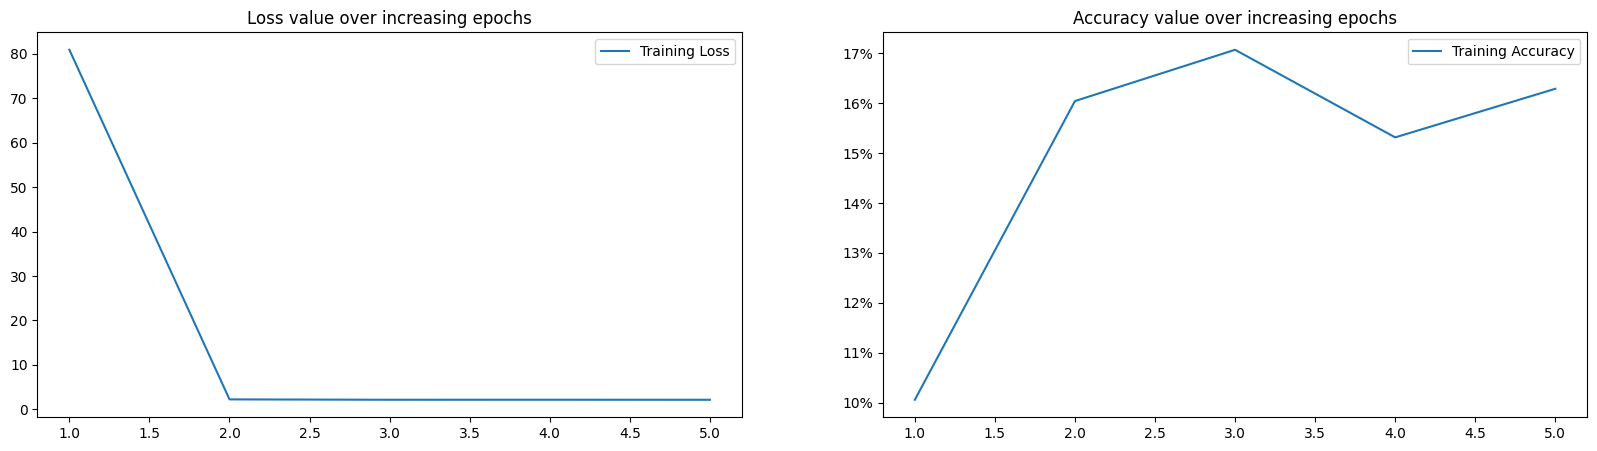

In [33]:
epochs = np.arange(5)+1
plt.figure(figsize = (20,5)) #a figura
plt.subplot(121)
plt.title('Loss value over increasing epochs') #titulo do da esquerda
plt.plot(epochs, losses, label = 'Training Loss') #indice
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs') #titulo
plt.plot(epochs, accuracies, label='Training Accuracy') #indice de cima
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()]) #coloca os do numero do lado esquerdo od grafico da direita em porcentagem
plt.legend()